<a href="https://colab.research.google.com/github/emilshain/TerraCascade/blob/main/TerraCascade_Flood_Inference_Colab_GPU_Python312_Python39.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prithvi flood-extent inference

This notebook is limited to the model workflow: Sentinel-2 preparation, Prithvi-100M-sen1floods11 inference, validation, GeoJSON conversion, and a provenance-complete `HazardEvent` fixture.

**Scope:** water/flood segmentation only. Do not interpret this model output as landslide detection or operational flood verification.

**Input band order:** Blue (B02), Green (B03), Red (B04), Narrow NIR (B8A), SWIR1 (B11), SWIR2 (B12). The model expects a single six-band GeoTIFF in exactly this order.

In [1]:
# Colab setup: keep the managed Jupyter kernel (Python 3.12) unchanged.
# The legacy Prithvi-100M model stack runs in an isolated Python 3.9 environment.
import sys
from pathlib import Path

WORKDIR = Path('/content/prithvi_flood')
WORKDIR.mkdir(parents=True, exist_ok=True)

PY39_DIR = Path('/content/prithvi39')
PY39 = PY39_DIR / 'bin/python'

# Colab images no longer reliably ship an apt-installable Python 3.9.
# Use uv to install a self-contained CPython 3.9 runtime instead.
if not PY39.exists():
    !{sys.executable} -m pip install -q uv
    !{sys.executable} -m uv python install 3.9.18
    !{sys.executable} -m uv venv --seed --python 3.9.18 {PY39_DIR}

!{PY39} -m pip install -q --upgrade pip setuptools wheel
!{sys.executable} -m pip install -q rasterio shapely matplotlib huggingface_hub

print('Notebook kernel:', sys.version.split()[0])
assert sys.version_info[:2] >= (3, 9), (
    f'Expected the notebook kernel to be Python >= 3.9, got {sys.version}'
)
print('Legacy inference runtime:', end=' ')
!{PY39} -c "import sys; print(sys.version)"
!{PY39} -c "import sys; assert sys.version_info[:2] == (3, 9); print('Python 3.9 runtime OK')"
print('Working directory:', WORKDIR)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 46.0 MB/s eta 0:00:00
Installed Python 3.9.18 in 1.71s
 + cpython-3.9.18-linux-x86_64-gnu (python3.9)
Using CPython 3.9.18
Creating virtual environment with seed packages at: prithvi39
 + packaging==26.3
 + pip==26.0.1
 + setuptools==82.0.1
 + wheel==0.48.0
Activate with: source prithvi39/bin/activate
Notebook kernel: 3.12.13
Legacy inference runtime: 3.9.18 (main, Feb 25 2024, 04:21:36) 
[Clang 17.0.6 ]
Python 3.9 runtime OK
Working directory: /content/prithvi_flood


In [2]:
# GPU check. In Colab use Runtime > Change runtime type > GPU.
# Do not change the Python kernel; the legacy model uses the separate Python 3.9 runtime.
!nvidia-smi
print('NVIDIA GPU detected above. The notebook is configured for the Colab GPU accelerator.')


Fri Aug 14 17:29:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Runtime architecture:
#   Notebook/Jupyter kernel: Python 3.12
#   Legacy Prithvi inference: isolated Python 3.9 environment
#   Accelerator: Colab NVIDIA GPU
#
# Do not replace the managed Colab kernel or /usr/bin/python3.
print('Python 3.12 notebook kernel + isolated Python 3.9 model runtime + Colab GPU')


Python 3.12 notebook kernel + isolated Python 3.9 model runtime + Colab GPU


In [4]:
import sys
print('Notebook kernel:', sys.version)
assert sys.version_info[:2] >= (3, 9), 'This notebook should run on a Python >= 3.9 kernel.'


Notebook kernel: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [5]:
print('Legacy inference interpreter:', PY39)
!{PY39} -c "import sys; print(sys.version)"


Legacy inference interpreter: /content/prithvi39/bin/python
3.9.18 (main, Feb 25 2024, 04:21:36) 
[Clang 17.0.6 ]


In [6]:
# Keep Colab's managed Python 3.12 Jupyter kernel intact.
# The Python 3.9 runtime is invoked explicitly through PY39 for the legacy model.
assert PY39.exists(), 'Run the Colab setup cell first.'
print('Runtime configuration confirmed: Python 3.12 kernel / Python 3.9 legacy runtime / GPU accelerator')


Runtime configuration confirmed: Python 3.12 kernel / Python 3.9 legacy runtime / GPU accelerator


In [7]:
import sys
print('Notebook kernel:', sys.version.split()[0])


Notebook kernel: 3.12.13


In [8]:
print('Python 3.9 legacy runtime:', end=' ')
!{PY39} --version


Python 3.9 legacy runtime: Python 3.9.18


In [9]:
import sys
print('Notebook kernel:', sys.version.split()[0])
print('Model runtime:', end=' ')
!{PY39} -c "import sys; print(sys.version.split()[0])"


Notebook kernel: 3.12.13
Model runtime: 3.9.18


## 0. Runtime requirements

This notebook uses two Python layers deliberately:

- **Notebook/Jupyter kernel:** Python 3.12 (the managed Colab kernel).
- **Model inference runtime:** isolated Python 3.9 at `/content/prithvi39`.
- **Accelerator:** Colab NVIDIA GPU.

The original Prithvi-100M Sen1Floods11 inference stack uses the legacy MMSegmentation/MMCV APIs. Do not mix this legacy stack with TerraTorch or the newer Prithvi-EO-2.0 stack.

The notebook never replaces Colab's managed kernel or `/usr/bin/python3`; cells that run the legacy model call the Python 3.9 interpreter explicitly through `PY39`.


In [10]:
assert PY39.exists(), 'Run the Colab setup cell first.'
assert sys.version_info[:2] >= (3, 9), f'Notebook kernel must be Python >= 3.9, got {sys.version}'
print('Notebook work:', sys.version.split()[0])
print('Model inference:', end=' ')
!{PY39} -c "import sys; assert sys.version_info[:2] == (3, 9); print(sys.version)"
print('Working directory:', WORKDIR)


Notebook work: 3.12.13
Model inference: 3.9.18 (main, Feb 25 2024, 04:21:36) 
[Clang 17.0.6 ]
Working directory: /content/prithvi_flood


## 1. Install the official legacy inference dependencies

This follows the NASA IMPACT `hls-foundation-os` inference path used by the model card. Run once per new Colab session. The final command verifies that the isolated Python 3.9 environment can see the selected GPU.

In [11]:
%cd /content
!test -d hls-foundation-os || git clone --depth 1 https://github.com/NASA-IMPACT/hls-foundation-os.git
%cd /content/hls-foundation-os

# Legacy Prithvi-100M Sen1Floods11 stack: Python 3.9 + torch 1.11 + CUDA 11.5.
# The model process is launched with PY39, while the notebook kernel remains Python 3.12.
!{PY39} -m pip install -q torch==1.11.0+cu115 torchvision==0.12.0+cu115 -f https://download.pytorch.org/whl/torch_stable.html
!{PY39} -m pip install -q -e .
!{PY39} -m pip install -q -U openmim
!{PY39} -m mim install 'mmcv-full==1.6.2' -f https://download.openmmlab.com/mmcv/dist/cu115/torch1.11.0/index.html
!{PY39} -m pip install -q 'mmsegmentation==0.30.0' 'numpy<2.0.0' rasterio shapely matplotlib huggingface_hub

# Final GPU/runtime verification.
!{PY39} -c "import sys, torch; assert sys.version_info[:2] == (3, 9); assert torch.cuda.is_available(), 'No NVIDIA GPU: set Runtime > Change runtime type > GPU and reconnect'; print('Python:', sys.version); print('Torch:', torch.__version__); print('GPU:', torch.cuda.get_device_name(0))"


/content
Cloning into 'hls-foundation-os'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 30 (delta 2), reused 13 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 1.38 MiB | 25.23 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/hls-foundation-os
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Building editable for geospatial_fm (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ..

## 2. Locate and unpack the Sentinel-2 L2A scene

The next cell mounts Google Drive when running in Colab. Put the uploaded `.SAFE.zip` in `MyDrive/terracascade/` or change `SCENE_ZIP_PATH`. The notebook discovers the six required band files rather than relying on pasted paths.

In [12]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except ImportError:
    print('Not running in Colab; use a local path for SCENE_ZIP_PATH.')

# Upload the .SAFE.zip to this Drive folder, or replace this path.
SCENE_ZIP_PATH = Path('/content/drive/MyDrive/terracascade/S2B_MSIL2A_20260810T050649_N0512_R019_T43PGM_20260810T085431.SAFE.zip')
assert SCENE_ZIP_PATH.exists(), f'Missing scene archive: {SCENE_ZIP_PATH}'

import shutil
SCENE_DIR = WORKDIR / 'scene'
if not SCENE_DIR.exists():
    shutil.unpack_archive(SCENE_ZIP_PATH, WORKDIR)
    extracted = next(WORKDIR.glob('*.SAFE'))
    extracted.rename(SCENE_DIR)

def find_one(pattern):
    matches = list(SCENE_DIR.rglob(pattern))
    if len(matches) != 1:
        raise RuntimeError(f'Expected one {pattern}; found {len(matches)}: {matches}')
    return matches[0]

band_paths = {
    'B02': find_one('*_B02_10m.jp2'), 'B03': find_one('*_B03_10m.jp2'),
    'B04': find_one('*_B04_10m.jp2'), 'B8A': find_one('*_B8A_20m.jp2'),
    'B11': find_one('*_B11_20m.jp2'), 'B12': find_one('*_B12_20m.jp2'),
}
band_paths# Colab asks you to authorize Drive access once per session.

Mounted at /content/drive


{'B02': PosixPath('/content/prithvi_flood/scene/GRANULE/L2A_T43PGM_A049237_20260810T052431/IMG_DATA/R10m/T43PGM_20260810T050649_B02_10m.jp2'),
 'B03': PosixPath('/content/prithvi_flood/scene/GRANULE/L2A_T43PGM_A049237_20260810T052431/IMG_DATA/R10m/T43PGM_20260810T050649_B03_10m.jp2'),
 'B04': PosixPath('/content/prithvi_flood/scene/GRANULE/L2A_T43PGM_A049237_20260810T052431/IMG_DATA/R10m/T43PGM_20260810T050649_B04_10m.jp2'),
 'B8A': PosixPath('/content/prithvi_flood/scene/GRANULE/L2A_T43PGM_A049237_20260810T052431/IMG_DATA/R20m/T43PGM_20260810T050649_B8A_20m.jp2'),
 'B11': PosixPath('/content/prithvi_flood/scene/GRANULE/L2A_T43PGM_A049237_20260810T052431/IMG_DATA/R20m/T43PGM_20260810T050649_B11_20m.jp2'),
 'B12': PosixPath('/content/prithvi_flood/scene/GRANULE/L2A_T43PGM_A049237_20260810T052431/IMG_DATA/R20m/T43PGM_20260810T050649_B12_20m.jp2')}

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Build a six-band GeoTIFF for the AOI

Enter the AOI bounds in WGS84. Crop before inference: a full Sentinel-2 tile is unnecessarily large and can exhaust GPU memory. The output is explicitly written with the GeoTIFF driver; copying a JP2 profile was the cause of the previous write failure.

In [14]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds, reproject

# Replace with the reviewed AOI boundary: west, south, east, north (EPSG:4326).
AOI_NAME = 'Idamalayar AOI'
AOI_BOUNDS_WGS84 = (76.65, 10.14, 76.80, 10.36)
BAND_ORDER = ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12']

with rasterio.open(band_paths['B02']) as ref_src:
    bounds = transform_bounds('EPSG:4326', ref_src.crs, *AOI_BOUNDS_WGS84, densify_pts=21)
    ref_window = from_bounds(*bounds, transform=ref_src.transform).round_offsets().round_lengths()
    ref_transform = ref_src.window_transform(ref_window)
    ref_crs = ref_src.crs
    height, width = int(ref_window.height), int(ref_window.width)
    assert height > 0 and width > 0, 'AOI does not overlap the Sentinel-2 scene'

stack = np.zeros((6, height, width), dtype=np.float32)
for i, band in enumerate(BAND_ORDER):
    with rasterio.open(band_paths[band]) as src:
        reproject(
            source=rasterio.band(src, 1), destination=stack[i],
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=ref_transform, dst_crs=ref_crs,
            dst_shape=(height, width), resampling=Resampling.bilinear,
        )

STACKED_TIF = WORKDIR / 'idamalayar_6band_input.tif'
profile = {'driver': 'GTiff', 'height': height, 'width': width, 'count': 6, 'dtype': 'float32',
           'crs': ref_crs, 'transform': ref_transform, 'compress': 'deflate'}
with rasterio.open(STACKED_TIF, 'w', **profile) as dst:
    dst.write(stack)
    dst.descriptions = tuple(BAND_ORDER)
print(STACKED_TIF, stack.shape, BAND_ORDER)

/content/prithvi_flood/idamalayar_6band_input.tif (6, 2442, 1656) ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12']


/tmp/ipykernel_836/1415397510.py:3: RuntimeWarning: invalid value encountered in divide
  rgb = np.clip(rgb / np.percentile(rgb, 98), 0, 1).transpose(1, 2, 0)


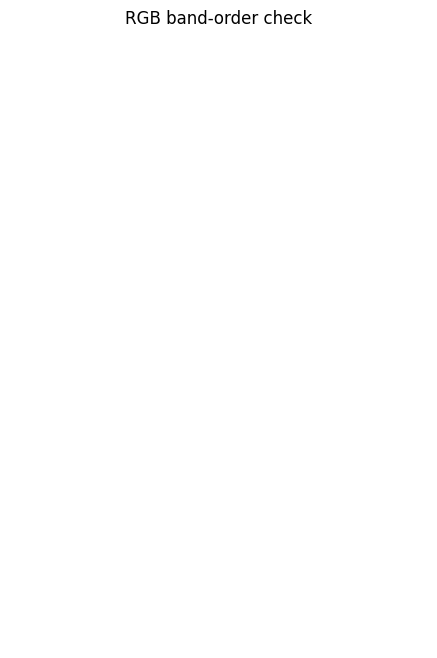

In [15]:
import matplotlib.pyplot as plt
rgb = stack[[2, 1, 0]]
rgb = np.clip(rgb / np.percentile(rgb, 98), 0, 1).transpose(1, 2, 0)
plt.figure(figsize=(8, 8)); plt.imshow(rgb); plt.title('RGB band-order check'); plt.axis('off');
assert rasterio.open(STACKED_TIF).count == 6

## 4. Download the exact model files and run the official inference script

The legacy repository name redirects to `ibm-nasa-geospatial/Prithvi-EO-1.0-100M-sen1floods11`. Save the resolved repository and file paths in the provenance record. The model output labels are 0 = no water, 1 = water/flood, -1 = no data/cloud.

In [16]:
from huggingface_hub import hf_hub_download
MODEL_REPOSITORY = 'ibm-nasa-geospatial/Prithvi-EO-1.0-100M-sen1floods11'
config_path = hf_hub_download(MODEL_REPOSITORY, 'sen1floods11_Prithvi_100M.py')
checkpoint_path = hf_hub_download(MODEL_REPOSITORY, 'sen1floods11_Prithvi_100M.pth')
print(config_path, checkpoint_path, sep='\n')

INPUT_DIR, OUTPUT_DIR = WORKDIR / 'inference_input', WORKDIR / 'inference_output'
INPUT_DIR.mkdir(exist_ok=True); OUTPUT_DIR.mkdir(exist_ok=True)
shutil.copy2(STACKED_TIF, INPUT_DIR / STACKED_TIF.name)
%cd /content/hls-foundation-os
!MPLBACKEND=Agg {PY39} model_inference.py -config {config_path} -ckpt {checkpoint_path} -input {INPUT_DIR} -output {OUTPUT_DIR} -input_type tif -bands 0 1 2 3 4 5
print(list(OUTPUT_DIR.rglob('*')))

sen1floods11_Prithvi_100M.py:   0%|          | 0.00/7.72k [00:00<?, ?B/s]

sen1floods11_Prithvi_100M.pth: reconstructing file:   0%|          |  0.00B / 1.20GB            

sen1floods11_Prithvi_100M.pth: downloading bytes:           |  0.00B            

/root/.cache/huggingface/hub/models--ibm-nasa-geospatial--Prithvi-EO-1.0-100M-sen1floods11/snapshots/86668a4feac50e0b6ce5f373c06297187fe20e33/sen1floods11_Prithvi_100M.py
/root/.cache/huggingface/hub/models--ibm-nasa-geospatial--Prithvi-EO-1.0-100M-sen1floods11/snapshots/86668a4feac50e0b6ce5f373c06297187fe20e33/sen1floods11_Prithvi_100M.pth
/content/hls-foundation-os
/content/prithvi39/lib/python3.9/site-packages/mmseg/models/decode_heads/decode_head.py:104: UserWarning: For binary segmentation, we suggest using`out_channels = 1` to define the outputchannels of segmentor, and use `threshold`to convert seg_logist into a predictionapplying a threshold
  warnings.warn('For binary segmentation, we suggest using'
/content/prithvi39/lib/python3.9/site-packages/mmseg/models/losses/cross_entropy_loss.py:235: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entro

## 5. Validate the mask, polygonise flood pixels, and create the fixture

Set `MASK_TIF` to the raster emitted by `model_inference.py`. Inspect the overlay before accepting the result. Remove very small polygons to avoid pixel-scale noise; this threshold is a demo simplification, not model confidence.

12387 flood polygons written


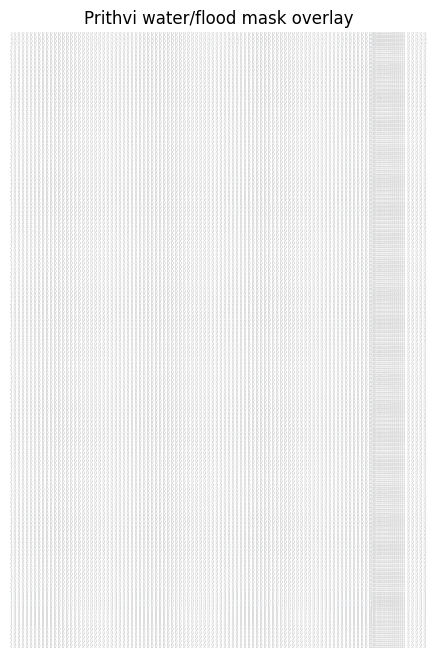

In [17]:
from datetime import datetime, timezone
import json
from shapely.geometry import shape, mapping
from rasterio.features import shapes

MASK_TIF = next(OUTPUT_DIR.rglob('*.tif'))  # verify this is the predicted-label raster, not a visualisation
with rasterio.open(MASK_TIF) as src:
    mask = src.read(1)
    assert mask.shape == (height, width), (mask.shape, (height, width))

plt.figure(figsize=(8, 8)); plt.imshow(rgb); plt.imshow(np.ma.masked_where(mask != 1, mask), cmap='Blues', alpha=.55); plt.title('Prithvi water/flood mask overlay'); plt.axis('off');

MIN_POLYGON_AREA_M2 = 2_500
features = []
for geometry, value in shapes((mask == 1).astype('uint8'), mask=(mask == 1), transform=ref_transform):
    polygon = shape(geometry)
    if polygon.area >= MIN_POLYGON_AREA_M2:
        feature_id = f'flood-zone-{len(features) + 1:03d}'
        features.append({'type': 'Feature', 'id': feature_id, 'properties': {'id': feature_id}, 'geometry': mapping(polygon)})

flood_extent = {'type': 'FeatureCollection', 'features': features}
assert features, 'No polygons remain: verify the predicted mask and AOI before continuing.'
(WORKDIR / 'flood_extent.geojson').write_text(json.dumps(flood_extent, indent=2))
print(f'{len(features)} flood polygons written')

In [19]:
SCENE_ID = 'S2B_MSIL2A_20260810T050649_N0512_R019_T43PGM_20260810T085431'
SCENE_ACQUIRED_AT = '2026-08-10T05:06:49Z'
RUN_AT = datetime.now(timezone.utc).isoformat().replace('+00:00', 'Z')
hazard_event = {
    'id': 'flood-idamalayar-20260810', 'hazard': 'flood', 'severity': 'orange',
    'source': f'Prithvi-100M-sen1floods11 inference ({MODEL_REPOSITORY}), Sentinel-2 L2A scene {SCENE_ID} acquired {SCENE_ACQUIRED_AT}, {AOI_NAME}',
    'status': 'verified-demo', 'issuedAt': SCENE_ACQUIRED_AT,
    'affectedZones': [feature['id'] for feature in features],
    'limitations': ['single-timestamp inference', 'not a live feed', 'demo AOI only', 'cloud-sensitive optical input; not ground-truthed'],
}
provenance = {
    'model': 'Prithvi-100M-sen1floods11', 'resolvedModelRepository': MODEL_REPOSITORY,
    'configPath': str(config_path), 'checkpointPath': str(checkpoint_path),
    'inputBands': BAND_ORDER, 'sceneId': SCENE_ID, 'sceneAcquiredAt': SCENE_ACQUIRED_AT,
    'aoiName': AOI_NAME, 'aoiBoundsWgs84': AOI_BOUNDS_WGS84, 'runAt': RUN_AT,
    'maskFile': str(MASK_TIF), 'minimumPolygonAreaM2': MIN_POLYGON_AREA_M2,
}
fixture = {'hazardEvent': hazard_event, 'floodExtent': flood_extent, 'provenance': provenance}
FIXTURE_PATH = WORKDIR / 'hazard_event_fixture.json'
FIXTURE_PATH.write_text(json.dumps(fixture, indent=2))
print(FIXTURE_PATH)


from google.colab import files

# Automatically download the generated files to your computer
files.download('/content/prithvi_flood/hazard_event_fixture.json')
files.download('/content/prithvi_flood/flood_extent.geojson')


/content/prithvi_flood/hazard_event_fixture.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Outputs

- `flood_extent.geojson`: model-derived water/flood polygons.
- `hazard_event_fixture.json`: the `HazardEvent`, GeoJSON, and full provenance record.

Only accept and distribute these files after the mask overlay has been manually checked for incorrect band order, cloud/no-data artefacts, and AOI alignment.